**Code from weeks 1 and 2**

In [3]:
# setup and imports
!unzip -o "UCI HAR Dataset.zip"

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Archive:  UCI HAR Dataset.zip
  inflating: UCI HAR Dataset/.DS_Store  
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features_info.txt  
  inflating: UCI HAR Dataset/README.txt  
  inflating: __MACOSX/UCI HAR Dataset/._README.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_x_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_y_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_z_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_z_t

In [4]:
# reproducibility
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seeds(42)

In [5]:
# load inertial signals
data_directory = Path("UCI HAR Dataset")

def load_inertial(split):
    base = data_directory / split / "Inertial Signals"
    names = [
        "body_acc_x_", "body_acc_y_", "body_acc_z_",
        "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
        "total_acc_x_", "total_acc_y_", "total_acc_z_"
    ]

    signals = []
    for name in names:
        arr = np.loadtxt(base / f"{name}{split}.txt")   # (N, T)
        signals.append(arr[:, :, None])                 # (N, T, 1)

    X = np.concatenate(signals, axis=2)                # (N, T, C=9)
    y = np.loadtxt(data_directory / split / f"y_{split}.txt").astype(int) - 1
    subjects = np.loadtxt(data_directory / split / f"subject_{split}.txt").astype(int)

    return X, y, subjects

X_train, y_train, subj_train = load_inertial("train")
X_test, y_test, subj_test = load_inertial("test")

# remove duplicates- each subject generates many windows, so get the unique ids that appear in each set
train_subjects = set(subj_train)
test_subjects = set(subj_test)

# check train and test are disjoint:
train_test_overlap = train_subjects & test_subjects
print("Is there any train test overlap?", "no" if len(train_test_overlap)==0 else "yes")

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

Is there any train test overlap? no


In [6]:
# subject-disjoin train/val split
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, val_idx = next(gss.split(X_train, y_train, groups=subj_train))

X_tr, y_tr = X_train[train_idx], y_train[train_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

subj_tr = subj_train[train_idx]
subj_val = subj_train[val_idx]

train_val_overlap = set(subj_tr).intersection(set(subj_val))
print("Train/Val subject intersection size (must be 0):", len(train_val_overlap))

print("Train subset shape:", X_tr.shape)
print("Val subset shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train/Val subject intersection size (must be 0): 0
Train subset shape: (5551, 128, 9)
Val subset shape: (1801, 128, 9)
Test shape: (2947, 128, 9)


In [7]:
# normalize, but don't flatten
# week 2 trained an MLP which requires flat feature vector, but GRU/LSTM preserves the time dimension

# compute mean and std value for each sensor channel
channel_mean = X_tr.mean(axis=(0, 1), keepdims=True)   # shape (1, 1, C)
channel_std = X_tr.std(axis=(0, 1), keepdims=True)     # shape (1, 1, C)

# safety against dividing by zero
channel_std[channel_std == 0] = 1.0

# normalize all splits using train statistics only
X_tr_norm = (X_tr - channel_mean) / channel_std
X_val_norm = (X_val - channel_mean) / channel_std
X_test_norm = (X_test - channel_mean) / channel_std

print("Normalized train shape:", X_tr_norm.shape)
print("Normalized val shape:", X_val_norm.shape)
print("Normalized test shape:", X_test_norm.shape)

Normalized train shape: (5551, 128, 9)
Normalized val shape: (1801, 128, 9)
Normalized test shape: (2947, 128, 9)


In [8]:
# tensor datasets and dataloaders for sequence model
train_ds = TensorDataset(
    torch.tensor(X_tr_norm, dtype=torch.float32),
    torch.tensor(y_tr, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val_norm, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test_norm, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 44
Val batches: 8
Test batches: 12


In [9]:
# device (standard practice)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [10]:
# evaluation function to be used for both GRU and LSTM
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_true = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = loss_fn(logits, yb)

            total_loss += loss.item() * len(xb)

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_true.append(yb.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)

    return avg_loss, acc

In [11]:
# training loop with gradient clipping and early stopping
def train_model(model, train_loader, val_loader, epochs, lr, weight_decay,
                clip_norm=1.0, early_stop_patience=5):
    # choosing clip_norm = 1.0 as common standard vals
    # allowing 5 consecutive epochs without improvement before stopping to compromise on training time
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_epoch = 0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        all_preds, all_true = [], []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()

            # required for RNNs unless justified otherwise
            if clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)

            optimizer.step()

            total_loss += loss.item() * len(xb)

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())

        train_loss = total_loss / len(train_loader.dataset)
        train_acc = accuracy_score(np.concatenate(all_true), np.concatenate(all_preds))

        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.3f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.3f}")

        if early_stop_patience is not None and no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc, best_epoch

In [12]:
# final evaluation helper
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_true.append(yb.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)
    return y_true, y_pred

### 11. Core sequence model: GRU or LSTM that consumes (batch, T, C) windows and outputs class logits. Include at least one regularization choice (dropout and/or weight decay)

In [13]:
# 11. Core sequence model — GRU
"""
model to classify a sensor time-series window into one of the six human activity classes
input_size = # of sensor features per timestep (9)
hidden_size = size of GRU hidden state
num_layers = # of stacked GRU layers
num_classes = # of output classes (6)
dropout = dropout rate for regularization, 30% of neurons will be temporarily disabled

Architecture:
sensor window --> GRU --> final hidden state --> dropout --> linear classifier --> logit
"""
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()

        """
        define GRU layer
        input format: (batch, time, features)
        """
        self.gru = nn.GRU(
            input_size=input_size,      # number of features per timestep
            hidden_size=hidden_size,    # size of hidden state
            num_layers=num_layers,      # stacked GRU layers
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0 # dropout only works with multiple layers
        )

        # define dropout to randomly disable 30% of neurons during training
        self.dropout = nn.Dropout(dropout)

        # define final classification layer, converts GRU representation into class scores/logits
        self.fc = nn.Linear(hidden_size, num_classes)

    # forward pass
    def forward(self, x):
        # run the gru, get first output 'out' and second output 'h_n'
        out, h_n = self.gru(x)

        # take the final hidden state from the last GRU layer (feautres GRU learned from the sequence)
        last_hidden = h_n[-1]   # shape: (batch, hidden_size)

        # apply dropout regularization
        last_hidden = self.dropout(last_hidden)

        # compute class logits
        logits = self.fc(last_hidden)
        return logits

### 12. Training robustness:  use gradient clipping (required for RNNs unless you justify why not). Use early stopping or LR scheduling

In [14]:
# initialize and train the GRU model
# 12. Training robustness — train GRU with gradient clipping + early stopping

set_seeds(42)

input_size = X_tr_norm.shape[2]   # C = 9 sensor channels
hidden_size = 64 # middle ground
num_layers = 2 # layer 1 to learn basic motion signals, layer 2 to learn higher-level activity patterns
num_classes = 6
dropout = 0.3

model = GRUClassifier(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=dropout
).to(device)

history, best_val_acc, best_epoch = train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-3,
    weight_decay=1e-4,       # regularization choice
    clip_norm=1.0,           # required for RNN robustness
    early_stop_patience=5    # required robustness choice: early stopping
)

print("Best validation accuracy:", best_val_acc)
print("Best validation epoch:", best_epoch)

Epoch 01 | train loss 1.4906 acc 0.368 | val loss 1.2089 acc 0.440
Epoch 02 | train loss 0.9962 acc 0.572 | val loss 0.7259 acc 0.701
Epoch 03 | train loss 0.5858 acc 0.769 | val loss 0.4299 acc 0.898
Epoch 04 | train loss 0.3400 acc 0.903 | val loss 0.1729 acc 0.970
Epoch 05 | train loss 0.2050 acc 0.928 | val loss 0.1730 acc 0.947
Epoch 06 | train loss 0.1805 acc 0.931 | val loss 0.0991 acc 0.978
Epoch 07 | train loss 0.1702 acc 0.931 | val loss 0.0836 acc 0.986
Epoch 08 | train loss 0.1553 acc 0.939 | val loss 0.1665 acc 0.955
Epoch 09 | train loss 0.1524 acc 0.938 | val loss 0.1404 acc 0.962
Epoch 10 | train loss 0.1478 acc 0.938 | val loss 0.0752 acc 0.982
Epoch 11 | train loss 0.1411 acc 0.941 | val loss 0.0922 acc 0.974
Epoch 12 | train loss 0.1476 acc 0.936 | val loss 0.1532 acc 0.954
Early stopping at epoch 12. Best epoch: 7
Best validation accuracy: 0.9861188228761799
Best validation epoch: 7


### 13. Final  evaluation: evaluate your best checkpoint on held-out test subjects. Provide confusion matrix, per-class performance, and a 3–5 sentence error analysis (which classes confuse, why plausible)

In [15]:
# 13. Final evaluation on held-out test subjects

test_loss, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

y_true, y_pred = get_predictions(model, test_loader, device)

print("\nPer-class performance:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

Test loss: 0.3126
Test accuracy: 0.9009

Per-class performance:

                    precision    recall  f1-score   support

           WALKING      0.963     0.889     0.925       496
  WALKING_UPSTAIRS      0.877     0.987     0.929       471
WALKING_DOWNSTAIRS      0.920     0.960     0.939       420
           SITTING      0.879     0.692     0.774       491
          STANDING      0.791     0.882     0.834       532
            LAYING      0.993     1.000     0.996       537

          accuracy                          0.901      2947
         macro avg      0.904     0.902     0.900      2947
      weighted avg      0.903     0.901     0.899      2947



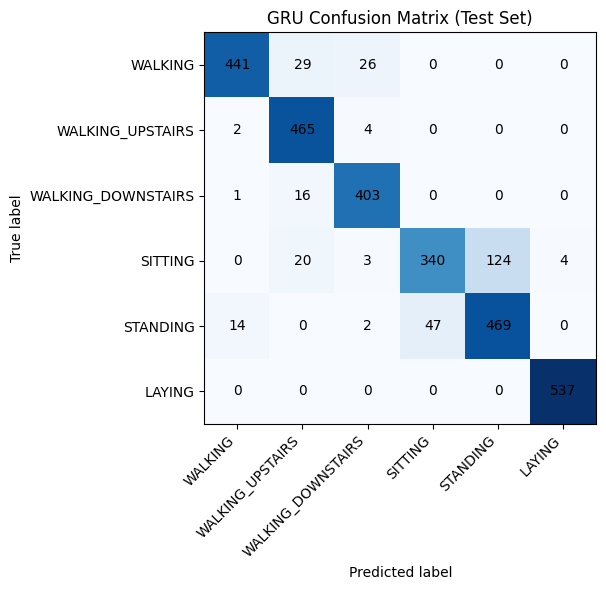

In [16]:
# confusion matrix
# Confusion matrix on held-out test set

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("GRU Confusion Matrix (Test Set)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

**Error Analysis:**

###  Inference function + latency (required): implement predict_activity(window) -> (label, probs). Time average inference per window over 100–500 windows on CPU in Colab and interpret feasibility for near-real-time use.

In [17]:
# 14. Inference function

def predict_activity(window):
    """
    Input:
        window: one IMU window of shape (T, C), e.g. (128, 9)

    Returns:
        label: predicted class name
        probs: numpy array of class probabilities, shape (6,)
    """

    model.eval()

    # convert input to numpy array if needed
    window = np.asarray(window, dtype=np.float32)

    # normalize using training-set statistics from earlier setup
    window = (window - channel_mean.squeeze(0)) / channel_std.squeeze(0)

    # add batch dimension: (T, C) -> (1, T, C)
    x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)                      # shape (1, 6)
        probs = torch.softmax(logits, dim=1)   # convert logits to probabilities
        probs = probs.squeeze(0).cpu().numpy()

    pred_idx = np.argmax(probs)
    label = class_names[pred_idx]

    return label, probs

In [18]:
# quick test on one sample
# Test predict_activity on one test window

sample_window = X_test[0]   # raw unnormalized test window
label, probs = predict_activity(sample_window)

print("Predicted label:", label)
print("Probabilities:", np.round(probs, 4))
print("Sum of probabilities:", probs.sum())

Predicted label: WALKING
Probabilities: [9.155e-01 4.500e-03 9.800e-03 4.000e-03 6.610e-02 1.000e-04]
Sum of probabilities: 0.9999998


In [19]:
# time average inference per window on CPU
# Measure average inference latency per window on CPU

cpu_model = model.to("cpu")
cpu_model.eval()

def predict_activity_cpu(window):
    window = np.asarray(window, dtype=np.float32)
    window = (window - channel_mean.squeeze(0)) / channel_std.squeeze(0)
    x = torch.tensor(window, dtype=torch.float32).unsqueeze(0)  # CPU tensor

    with torch.no_grad():
        logits = cpu_model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).numpy()

    pred_idx = np.argmax(probs)
    label = class_names[pred_idx]
    return label, probs

# use 200 windows from the test set
num_windows = 200
windows_for_timing = X_test[:num_windows]

start = time.time()
for window in windows_for_timing:
    _ = predict_activity_cpu(window)
end = time.time()

total_time = end - start
avg_time_ms = (total_time / num_windows) * 1000

print(f"Total time for {num_windows} windows: {total_time:.4f} seconds")
print(f"Average inference time per window: {avg_time_ms:.4f} ms")

Total time for 200 windows: 2.3942 seconds
Average inference time per window: 11.9709 ms


**Interpret Latency**

### 15. Model card + limitations: include intended use, non-intended use, evaluation protocol, known failure modes, and a short privacy/ethics note

# Model Card — GRU Activity Recognition Model

## Model Details
This model is a GRU-based sequence classifier trained on the UCI Human Activity Recognition (HAR) inertial signals dataset. It takes a fixed sensor window of shape `(128, 9)` as input, where the 9 channels are accelerometer and gyroscope-derived signals, and outputs one of 6 activity classes: WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, or LAYING.

## Intended Use
The intended use of this model is short-window human activity recognition from smartphone IMU sensor streams in a controlled setting similar to the UCI HAR dataset. It is appropriate for educational demonstration, prototyping, and basic activity classification experiments.

## Non-Intended Use
This model is not intended for medical diagnosis, fall detection in safety-critical systems, surveillance, identity inference, or any high-stakes monitoring scenario. It should also not be assumed to generalize to all device placements, populations, or real-world environments without further validation.

## Evaluation Protocol
The model was trained using a subject-disjoint training/validation/test setup. Training and validation splits were created only from the training subjects, and final evaluation was performed on held-out test subjects with no subject overlap. Metrics included test accuracy, confusion matrix, and per-class precision, recall, and F1-score.

## Known Failure Modes / Limitations
The model can confuse activities with similar motion patterns, especially SITTING vs STANDING and related walking activities. It only sees fixed-length windows and does not use longer-term context. Performance may also degrade if the phone is placed differently, if sensor noise differs, or if the user population differs from the benchmark dataset.

## Privacy / Ethics Note
Although this dataset is anonymized and based on motion sensor signals rather than raw audio/video, activity recognition still raises privacy concerns because motion patterns can reveal behavioral routines. Any real deployment should clearly inform users about what is being collected, minimize retention of sensor data, and avoid using predictions for surveillance or punitive decision-making.